In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df=pd.read_csv("Travel.csv")

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [5]:
cols = df.select_dtypes(include=['object']).columns
print(cols)

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='str')


In [6]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [7]:
df['Occupation'].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [9]:
df['ProductPitched'].value_counts()

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [10]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [11]:
df['Designation'].value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

In [12]:
df['Gender']=df['Gender'].replace('Fe male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [13]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [14]:
##Checking Missing Values
##these are features with nan values
features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')    

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [15]:
##statistics on numerical columns(Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [16]:
df.fillna({
    "Age": df.Age.median(),
    "DurationOfPitch": df.DurationOfPitch.median(),
    "NumberOfTrips": df.NumberOfTrips.median(),
    "MonthlyIncome": df.MonthlyIncome.median(),

    "NumberOfFollowups": df.NumberOfFollowups.mode()[0],
    "NumberOfChildrenVisiting": df.NumberOfChildrenVisiting.mode()[0],
    "PreferredPropertyStar": df.PreferredPropertyStar.mode()[0],

    "TypeofContact": df.TypeofContact.mode()[0]
}, inplace=True)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0


In [17]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [18]:
df.drop('CustomerID',inplace=True, axis=1)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   str    
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   str    
 6   Gender                    4888 non-null   str    
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   str    
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   str    
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSatisfactionSc

In [20]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [21]:
df['TotalVisiting']=df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']

In [22]:
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], inplace=True)

In [23]:
##GET ALL Numeric features
num_features=[feature for feature in df.columns if df[feature].dtype!='O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 18


In [24]:
cat_features=[ feature for feature in df.columns if df[feature].dtype=='O']
print('Num of Discrete Features :',len(cat_features))

Num of Discrete Features : 0


In [25]:
discrete_features=[feature for feature in df.columns if len(df[feature].unique())<=25]
print('Num of Numerical Features :', len(discrete_features))

Num of Numerical Features : 15


In [26]:
continous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continous features:',len(continous_features))

Num of Continous features: 3


In [27]:
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [28]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [29]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [30]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [31]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   str    
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   str    
 5   Gender                  4888 non-null   str    
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   str    
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   str    
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   str    
 15

In [32]:
cat_features=X.select_dtypes(include="object").columns
num_features=X.select_dtypes(exclude="object").columns

In [33]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first',handle_unknown='ignore')

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScalar",numeric_transformer,num_features)
    ]
)

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
X_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
2661,30.0,Self Enquiry,1,7.0,Large Business,Male,4.0,Basic,3.0,Unmarried,2.0,0,2,0,Executive,20736.0,4.0
4118,39.0,Self Enquiry,1,36.0,Small Business,Male,4.0,Deluxe,5.0,Married,2.0,1,3,1,Manager,25351.0,7.0
1130,36.0,Self Enquiry,1,34.0,Salaried,Male,1.0,Deluxe,3.0,Married,2.0,0,5,1,Manager,18407.0,2.0
2813,32.0,Self Enquiry,1,16.0,Salaried,Male,5.0,Basic,4.0,Unmarried,2.0,1,3,1,Executive,21335.0,4.0
2586,39.0,Self Enquiry,1,10.0,Large Business,Female,4.0,Deluxe,3.0,Unmarried,5.0,1,5,0,Manager,4678.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,36.0,Self Enquiry,1,16.0,Salaried,Male,3.0,Basic,3.0,Married,2.0,0,5,0,Executive,22347.0,2.0
1203,53.0,Self Enquiry,1,30.0,Small Business,Male,1.0,Standard,3.0,Married,4.0,0,3,0,Senior Manager,22005.0,3.0
1753,55.0,Self Enquiry,1,26.0,Large Business,Male,3.0,Deluxe,3.0,Married,4.0,1,1,0,Manager,20415.0,2.0
3336,20.0,Company Invited,1,17.0,Small Business,Female,5.0,Basic,4.0,Unmarried,3.0,1,5,1,Executive,20537.0,6.0


In [36]:
X_train = preprocessor.fit_transform(X_train)

In [37]:
X_test=preprocessor.transform(X_test)

In [38]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.71772,-1.001783,0.291028,-0.728113,-0.674975,-0.641126,-0.778021,-1.287655,-0.546868,-0.056638
1,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.71772,2.456333,0.291028,1.785726,-0.674975,1.559755,-0.045700,0.776605,0.343489,2.072717
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.71772,2.217842,-2.719341,-0.728113,-0.674975,-0.641126,1.418942,0.776605,-0.996194,-1.476207
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.71772,0.071425,1.294484,0.528806,-0.674975,1.559755,-0.045700,0.776605,-0.431305,-0.056638
4,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,-0.71772,-0.644047,0.291028,-0.728113,0.958501,1.559755,1.418942,-1.287655,-3.644884,-0.056638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.71772,0.071425,-0.712428,-0.728113,-0.674975,-0.641126,1.418942,-1.287655,-0.236063,-1.476207
3906,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-0.71772,1.740861,-2.719341,-0.728113,0.414009,-0.641126,-0.045700,-1.287655,-0.302044,-0.766422
3907,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.71772,1.263879,-0.712428,-0.728113,0.414009,1.559755,-1.510342,-1.287655,-0.608797,-1.476207
3908,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.71772,0.190671,1.294484,0.528806,-0.130483,1.559755,1.418942,0.776605,-0.585260,1.362932


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix

In [57]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities (for ROC AUC)
    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # Training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_roc_auc = roc_auc_score(y_train, y_train_proba[:, 1])
    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])

    # Print results
    print(name)

    print("Training Performance")
    print(f"- Accuracy: {train_accuracy:.4f}")
    print(f"- F1 Score: {train_f1:.4f}")
    print(f"- Precision: {train_precision:.4f}")
    print(f"- Recall: {train_recall:.4f}")
    print(f"- ROC AUC: {train_roc_auc:.4f}")

    print("-" * 40)

    print("Test Performance")
    print(f"- Accuracy: {test_accuracy:.4f}")
    print(f"- F1 Score: {test_f1:.4f}")
    print(f"- Precision: {test_precision:.4f}")
    print(f"- Recall: {test_recall:.4f}")
    print(f"- ROC AUC: {test_roc_auc:.4f}")

    print("=" * 50)

Logistic Regression
Training Performance
- Accuracy: 0.8450
- F1 Score: 0.8200
- Precision: 0.8294
- Recall: 0.8450
- ROC AUC: 0.8101
----------------------------------------
Test Performance
- Accuracy: 0.8456
- F1 Score: 0.8204
- Precision: 0.8249
- Recall: 0.8456
- ROC AUC: 0.8238
Decision Tree
Training Performance
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------------
Test Performance
- Accuracy: 0.9151
- F1 Score: 0.9145
- Precision: 0.9139
- Recall: 0.9151
- ROC AUC: 0.8478
Random Forest
Training Performance
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------------
Test Performance
- Accuracy: 0.9387
- F1 Score: 0.9351
- Precision: 0.9387
- Recall: 0.9387
- ROC AUC: 0.9800


In [41]:
## Hyperparamter tuning
rf_params={"max_depth":[5,8,15,None,10],
           "max_features":[5,7,"auto",8],
           "min_samples_split":[2,8,15,20],
           "n_estimators":[100,200,500,1000]}

In [42]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [43]:
randomcv_models=[
       ("RF",RandomForestClassifier(),rf_params),
]

In [44]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]})]

In [46]:
from sklearn.model_selection import RandomizedSearchCV

model_param={}
for name,model, params in randomcv_models:
    random=RandomizedSearchCV(estimator=model,
                              param_distributions=params,
                              n_iter=100,
                              cv=3,
                              verbose=2,
                              n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f"-----------------Best Params for {model_name}--------------------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
-----------------Best Params for RF--------------------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


In [54]:
models={"Random Forest":RandomForestClassifier(n_estimators= 500, min_samples_split= 2, max_features= 8, max_depth= None)
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)  # Train Model

    # Make predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #Training set performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_roauc_score=roc_auc_score(y_train,y_train_pred)


    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_roauc_score=roc_auc_score(y_test,y_test_pred)


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("-Accuracy: {:.4f}".format(model_train_accuracy))
    print("-F1 score: {:.4f}".format(model_train_f1))

    print("-Precision: {:.4f}".format(model_train_precision))
    print("-Recall: {:.4f}".format(model_train_recall))
    print("-Roc Auc Score: {:.4f}".format(model_train_roauc_score))


    print("-----------------------------------------")
    
    print('Model performance for Test set')
    print("-Accuracy: {:.4f}".format(model_test_accuracy))
    print("-F1 score: {:.4f}".format(model_test_f1))

    print("-Precision: {:.4f}".format(model_test_precision))
    print("-Recall: {:.4f}".format(model_test_recall))
    print("-Roc Auc Score: {:.4f}".format(model_test_roauc_score))

    print("="*35)
    print("\n")
    


Random Forest
Model performance for Training set
-Accuracy: 1.0000
-F1 score: 1.0000
-Precision: 1.0000
-Recall: 1.0000
-Roc Auc Score: 1.0000
-----------------------------------------
Model performance for Test set
-Accuracy: 0.9448
-F1 score: 0.9419
-Precision: 0.9481
-Recall: 0.7314
-Roc Auc Score: 0.8614




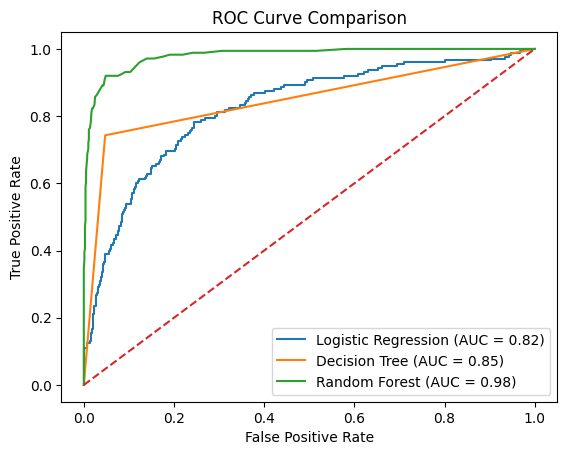

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, model in models.items():
    
    # Get probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()